In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import os

print("All imports successful!")

All imports successful!


In [4]:
np.random.seed(42)
n_samples = 10000

# Generate base features
data = {
    'soil_pH':       np.random.uniform(4.0, 9.0, n_samples),
    'nitrogen':      np.random.uniform(0, 140, n_samples),
    'phosphorus':    np.random.uniform(0, 140, n_samples),
    'potassium':     np.random.uniform(0, 140, n_samples),
    'temperature':   np.random.uniform(10, 45, n_samples),
    'humidity':      np.random.uniform(20, 100, n_samples),
    'rainfall':      np.random.uniform(0, 300, n_samples),
    'crop_age_days': np.random.randint(10, 120, n_samples).astype(float),
    'sunlight_hours': np.random.uniform(2, 12, n_samples),
}

df = pd.DataFrame(data)

# More nuanced disease assignment
def assign_disease(row):
    # Fungal — loves high humidity + warm temps
    if row['humidity'] > 78 and 20 < row['temperature'] < 35:
        return 'Fungal_Disease'
    # Bacterial — wet + warm + lots of rain
    elif row['humidity'] > 72 and row['rainfall'] > 180 and row['temperature'] > 22:
        return 'Bacterial_Disease'
    # Heat stress — very hot + dry
    elif row['temperature'] > 37 and row['humidity'] < 40 and row['rainfall'] < 60:
        return 'Heat_Stress'
    # Nutrient deficiency — poor soil pH + low nitrogen
    elif row['soil_pH'] < 5.5 and row['nitrogen'] < 35:
        return 'Nutrient_Deficiency'
    # Mineral deficiency — low potassium + phosphorus
    elif row['potassium'] < 25 and row['phosphorus'] < 25:
        return 'Mineral_Deficiency'
    # Overwatering — too much rain + low sunlight
    elif row['rainfall'] > 250 and row['sunlight_hours'] < 4:
        return 'Overwatering'
    # Healthy
    else:
        return 'Healthy'

df['disease'] = df.apply(assign_disease, axis=1)

print(f"Dataset shape: {df.shape}")
print(f"\nDisease distribution:")
dist = df['disease'].value_counts()
for disease, count in dist.items():
    bar = '█' * (count // 100)
    print(f"  {count:5d} {bar} {disease}")

Dataset shape: (10000, 10)

Disease distribution:
   7158 ███████████████████████████████████████████████████████████████████████ Healthy
   1189 ███████████ Fungal_Disease
    596 █████ Nutrient_Deficiency
    524 █████ Bacterial_Disease
    234 ██ Mineral_Deficiency
    194 █ Overwatering
    105 █ Heat_Stress


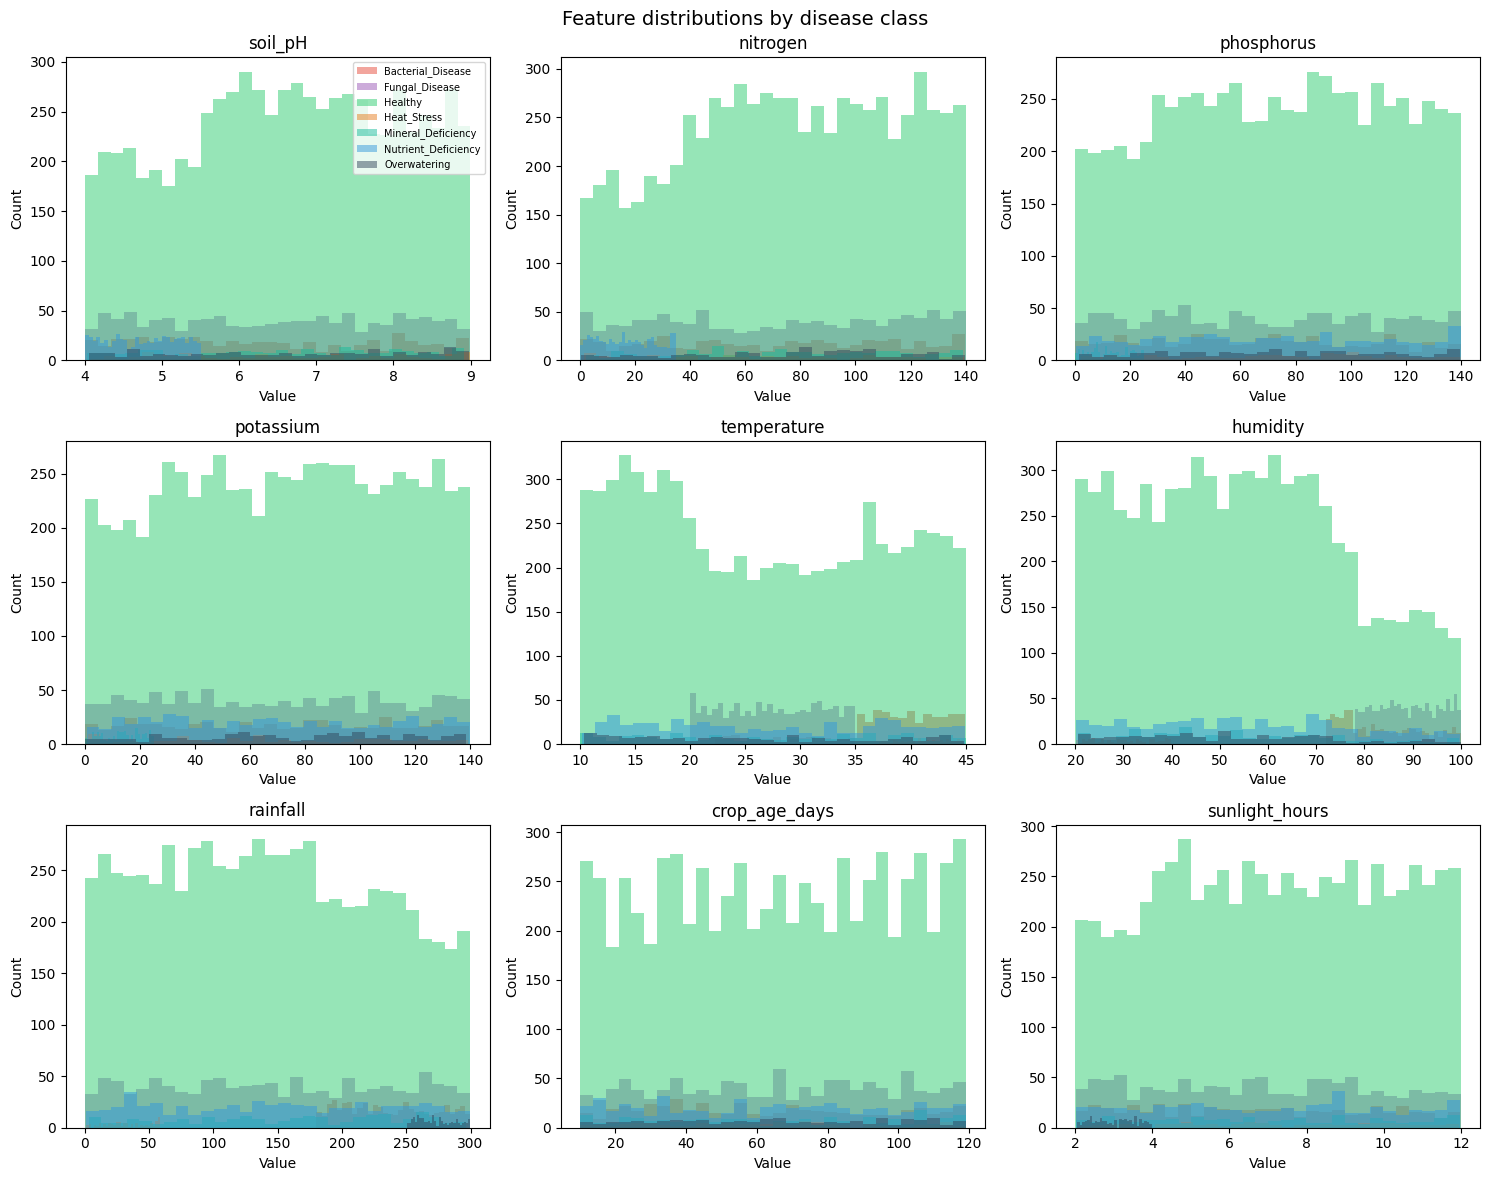

Saved to outputs/feature_distributions.png


In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

features = ['soil_pH', 'nitrogen', 'phosphorus', 'potassium',
            'temperature', 'humidity', 'rainfall', 'crop_age_days', 'sunlight_hours']

colors = {'Healthy': '#2ecc71', 'Fungal_Disease': '#9b59b6',
          'Bacterial_Disease': '#e74c3c', 'Heat_Stress': '#e67e22',
          'Nutrient_Deficiency': '#3498db', 'Mineral_Deficiency': '#1abc9c',
          'Overwatering': '#34495e'}

for i, feature in enumerate(features):
    for disease, group in df.groupby('disease'):
        axes[i].hist(group[feature], bins=30, alpha=0.5,
                    label=disease, color=colors[disease])
    axes[i].set_title(feature)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[0].legend(fontsize=7, loc='upper right')
plt.suptitle('Feature distributions by disease class', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/feature_distributions.png")

In [6]:
# Save the raw dataset
df.to_csv('data/tabular_features_v2.csv', index=False)

# Separate features and labels
feature_cols = ['soil_pH', 'nitrogen', 'phosphorus', 'potassium',
                'temperature', 'humidity', 'rainfall', 
                'crop_age_days', 'sunlight_hours']

X = df[feature_cols].values
y = df['disease'].values

# Encode labels
label_encoder_v2 = LabelEncoder()
y_encoded = label_encoder_v2.fit_transform(y)

print("Classes:")
for i, cls in enumerate(label_encoder_v2.classes_):
    print(f"  {i} → {cls}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# Scale
scaler_v2 = StandardScaler()
X_train_scaled = scaler_v2.fit_transform(X_train)
X_val_scaled   = scaler_v2.transform(X_val)
X_test_scaled  = scaler_v2.transform(X_test)

# Save
joblib.dump(scaler_v2, 'models/tabular_scaler_v2.pkl')
joblib.dump(label_encoder_v2, 'models/label_encoder_v2.pkl')

pipeline_data = {
    'feature_cols': feature_cols,
    'classes': list(label_encoder_v2.classes_),
    'n_classes': len(label_encoder_v2.classes_),
    'X_train': X_train_scaled,
    'X_val': X_val_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test
}

with open('data/processed/tabular_pipeline_v2.pkl', 'wb') as f:
    pickle.dump(pipeline_data, f)

print(f"\nSplit sizes:")
print(f"  Train: {X_train_scaled.shape}")
print(f"  Val:   {X_val_scaled.shape}")
print(f"  Test:  {X_test_scaled.shape}")
print("\nPipeline saved!")

Classes:
  0 → Bacterial_Disease
  1 → Fungal_Disease
  2 → Healthy
  3 → Heat_Stress
  4 → Mineral_Deficiency
  5 → Nutrient_Deficiency
  6 → Overwatering

Split sizes:
  Train: (6800, 9)
  Val:   (1200, 9)
  Test:  (2000, 9)

Pipeline saved!


In [7]:
# Write the preprocessing module to src/preprocessing.py
preprocessing_code = '''import numpy as np
import pandas as pd
import joblib
from PIL import Image
from torchvision import transforms

# Image transform for inference (no augmentation)
def get_inference_transform():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

def preprocess_image(image_path):
    """Load and preprocess a single image for inference."""
    transform = get_inference_transform()
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0)  # add batch dimension
    return tensor

def preprocess_tabular(features_dict, scaler_path="models/tabular_scaler_v2.pkl"):
    """
    Preprocess tabular features for inference.
    features_dict: {soil_pH, nitrogen, phosphorus, potassium,
                    temperature, humidity, rainfall,
                    crop_age_days, sunlight_hours}
    """
    feature_cols = ["soil_pH", "nitrogen", "phosphorus", "potassium",
                    "temperature", "humidity", "rainfall",
                    "crop_age_days", "sunlight_hours"]
    
    scaler = joblib.load(scaler_path)
    values = np.array([[features_dict[col] for col in feature_cols]])
    scaled = scaler.transform(values)
    return scaled

def load_label_encoder(path="models/label_encoder_v2.pkl"):
    """Load the label encoder."""
    return joblib.load(path)
'''

with open('src/preprocessing.py', 'w') as f:
    f.write(preprocessing_code)

print("src/preprocessing.py created!")

# Test it immediately
import sys
sys.path.append('.')
from src.preprocessing import preprocess_tabular, load_label_encoder

# Test with sample values
sample = {
    'soil_pH': 6.5,
    'nitrogen': 80,
    'phosphorus': 60,
    'potassium': 70,
    'temperature': 28,
    'humidity': 65,
    'rainfall': 120,
    'crop_age_days': 45,
    'sunlight_hours': 7
}

scaled = preprocess_tabular(sample)
print(f"\nSample input: {sample}")
print(f"Scaled output shape: {scaled.shape}")
print(f"Scaled values: {scaled.round(3)}")

src/preprocessing.py created!

Sample input: {'soil_pH': 6.5, 'nitrogen': 80, 'phosphorus': 60, 'potassium': 70, 'temperature': 28, 'humidity': 65, 'rainfall': 120, 'crop_age_days': 45, 'sunlight_hours': 7}
Scaled output shape: (1, 9)
Scaled values: [[ 0.018  0.235 -0.246  0.01   0.049  0.21  -0.348 -0.627 -0.004]]


In [ ]:
models_code = '''import torch
import torch.nn as nn
import numpy as np
import joblib
import pickle
import xgboost as xgb
from torchvision import models

def load_image_model(weights_path="models/resnet50_finetuned.pth", num_classes=15):
    """Load fine-tuned ResNet50 for feature extraction."""
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(2048, num_classes)
    model.load_state_dict(torch.load(weights_path, map_location="cpu"))
    model.eval()
    return model

def get_embedding_model(resnet):
    """Strip the final layer to get a feature extractor."""
    embedding_model = nn.Sequential(*list(resnet.children())[:-1])
    embedding_model.eval()
    return embedding_model

def load_fusion_model(weights_path="models/fusion_mlp_best.pth",
                      input_dim=2055, num_classes=15):
    """Load the fusion MLP."""
    class FusionMLP(nn.Module):
        def __init__(self, input_dim, num_classes):
            super().__init__()
            self.network = nn.Sequential(
                nn.Linear(input_dim, 512),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes)
            )
        def forward(self, x):
            return self.network(x)

    model = FusionMLP(input_dim, num_classes)
    model.load_state_dict(torch.load(weights_path, map_location="cpu"))
    model.eval()
    return model

def load_xgboost_model(model_path="models/xgboost_tabular.json"):
    """Load the XGBoost tabular model."""
    model = xgb.XGBClassifier()
    model.load_model(model_path)
    return model

def predict_fusion(image_tensor, tabular_array,
                   embedding_model, fusion_model, image_classes):
    """
    Run full fusion inference.
    Returns: predicted class name, confidence score
    """
    with torch.no_grad():
        # Get image embedding
        embedding = embedding_model(image_tensor)
        embedding = embedding.squeeze(-1).squeeze(-1).numpy()

        # Concatenate with tabular features
        fused = np.concatenate([embedding, tabular_array], axis=1)
        fused_tensor = torch.tensor(fused, dtype=torch.float32)

        # Run fusion model
        outputs = fusion_model(fused_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = probs.max(1)

        class_name = image_classes[predicted.item()]
        confidence_pct = round(confidence.item() * 100, 2)

    return class_name, confidence_pct
'''

with open('src/models.py', 'w') as f:
    f.write(models_code)

print("src/models.py created!")

# Test loading all models
from src.models import (load_image_model, get_embedding_model,
                        load_fusion_model, load_xgboost_model, predict_fusion)

resnet = load_image_model()
embedding_model = get_embedding_model(resnet)
fusion_model = load_fusion_model()
xgb_model = load_xgboost_model()

print("All models loaded successfully!")
print(f"  ResNet50 feature extractor: ✓")
print(f"  Fusion MLP: ✓")
print(f"  XGBoost: ✓")

src/models.py created!


In [1]:
print("Testing ResNet50...")
from src.models import load_image_model, get_embedding_model
resnet = load_image_model()
embedding_model = get_embedding_model(resnet)
print("ResNet50 loaded!")

Testing ResNet50...
ResNet50 loaded!


In [2]:
print("Testing Fusion MLP...")
from src.models import load_fusion_model
fusion_model = load_fusion_model()
print("Fusion MLP loaded!")

Testing Fusion MLP...
Fusion MLP loaded!


In [ ]:
print("Testing XGBoost...")
from src.models import load_xgboost_model
xgb_model = load_xgboost_model()
print("XGBoost loaded!")

In [8]:
import xgboost as xgb
import pickle
import joblib
import numpy as np

# Load the pipeline data we saved earlier today
with open('data/processed/tabular_pipeline_v2.pkl', 'rb') as f:
    pipeline_data = pickle.load(f)

X_train = pipeline_data['X_train']
y_train = pipeline_data['y_train']
X_val = pipeline_data['X_val']
y_val = pipeline_data['y_val']

# Retrain XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Save with joblib instead of json this time
joblib.dump(xgb_model, 'models/xgboost_tabular_v2.pkl')
print("XGBoost retrained and saved!")

[0]	validation_0-mlogloss:0.85650
[50]	validation_0-mlogloss:0.04060
[100]	validation_0-mlogloss:0.01651
[150]	validation_0-mlogloss:0.01487
[199]	validation_0-mlogloss:0.01480
XGBoost retrained and saved!


In [9]:
# Update the load_xgboost_model function in src/models.py
with open('src/models.py', 'r') as f:
    content = f.read()

old = 'def load_xgboost_model(model_path="models/xgboost_tabular.json"):\n    """Load the XGBoost tabular model."""\n    model = xgb.XGBClassifier()\n    model.load_model(model_path)\n    return model'

new = 'def load_xgboost_model(model_path="models/xgboost_tabular_v2.pkl"):\n    """Load the XGBoost tabular model."""\n    import joblib\n    model = joblib.load(model_path)\n    return model'

content = content.replace(old, new)

with open('src/models.py', 'w') as f:
    f.write(content)

print("src/models.py updated!")

# Now test loading all three again
from importlib import reload
import src.models
reload(src.models)
from src.models import load_xgboost_model

xgb_model = load_xgboost_model()
print("XGBoost loaded successfully!")

src/models.py updated!
XGBoost loaded successfully!


In [ ]:
from importlib import reload
import src.models
reload(src.models)
from src.models import (load_image_model, get_embedding_model,
                        load_fusion_model, load_xgboost_model, predict_fusion)
from src.preprocessing import preprocess_tabular

import pickle

# Load all models
resnet = load_image_model()
embedding_model = get_embedding_model(resnet)
fusion_model = load_fusion_model()

# Load image classes
with open('data/processed/data_splits.pkl', 'rb') as f:
    image_data = pickle.load(f)
image_classes = image_data['classes']

print("All models loaded!")

# Run a test prediction on a real image
test_image_path = image_data['test_paths'][0]
test_label = image_classes[image_data['test_labels'][0]]

# Preprocess image
from src.preprocessing import preprocess_image
image_tensor = preprocess_image(test_image_path)

# Preprocess tabular
sample_tabular = {
    'soil_pH': 6.5, 'nitrogen': 80, 'phosphorus': 60,
    'potassium': 70, 'temperature': 28, 'humidity': 65,
    'rainfall': 120, 'crop_age_days': 45, 'sunlight_hours': 7
}
tabular_array = preprocess_tabular(sample_tabular)

# Predict
class_name, confidence = predict_fusion(
    image_tensor, tabular_array,
    embedding_model, fusion_model, image_classes
)

print(f"\nTest image: {test_image_path.split('/')[-2]}")
print(f"True label:      {test_label}")
print(f"Predicted label: {class_name}")
print(f"Confidence:      {confidence}%")

In [1]:
import torch
import torch.nn as nn
import numpy as np
import joblib
import pickle
from torchvision import models
from src.preprocessing import preprocess_image, preprocess_tabular

# Load image classes
with open('data/processed/data_splits.pkl', 'rb') as f:
    image_data = pickle.load(f)
image_classes = image_data['classes']

print("Classes loaded!")
print(f"Free after loading classes — check RAM if needed")

Classes loaded!
Free after loading classes — check RAM if needed


In [2]:
# Load ResNet50 and get embedding
from src.models import load_image_model, get_embedding_model

resnet = load_image_model()
embedding_model = get_embedding_model(resnet)

# Preprocess test image
test_image_path = image_data['test_paths'][0]
test_label = image_classes[image_data['test_labels'][0]]
image_tensor = preprocess_image(test_image_path)

# Get embedding immediately and free resnet from memory
with torch.no_grad():
    embedding = embedding_model(image_tensor)
    embedding = embedding.squeeze(-1).squeeze(-1).numpy()

# Free memory
del resnet, embedding_model
import gc
gc.collect()

print(f"Image embedding extracted: {embedding.shape}")
print(f"True label: {test_label}")

Image embedding extracted: (1, 2048)
True label: Tomato_Late_blight


In [9]:
# Use only the embeddings we have (5000) and match tabular to that
n_total = len(embeddings)  # 5000

# Take first 5000 from tabular pipeline
X_tab_all = np.concatenate([
    pipeline_data['X_train'],
    pipeline_data['X_val'],
    pipeline_data['X_test']
], axis=0)[:n_total]

y_tab_all = np.concatenate([
    pipeline_data['y_train'],
    pipeline_data['y_val'],
    pipeline_data['y_test']
], axis=0)[:n_total]

# Fuse all 5000 samples
X_fused = np.concatenate([embeddings, X_tab_all], axis=1)
y_fused = image_labels  # use image labels as target

print(f"Fused shape: {X_fused.shape}")
print(f"Labels shape: {y_fused.shape}")

# Split
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_fused, y_fused, test_size=0.2, random_state=42, stratify=y_fused
)
X_tr, X_vl, y_tr, y_vl = train_test_split(
    X_tr, y_tr, test_size=0.15, random_state=42, stratify=y_tr
)

print(f"Train: {X_tr.shape} | Val: {X_vl.shape} | Test: {X_te.shape}")

Fused shape: (5000, 2057)
Labels shape: (5000,)
Train: (3400, 2057) | Val: (600, 2057) | Test: (1000, 2057)


In [10]:
# Convert to tensors
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
X_vl_t = torch.tensor(X_vl, dtype=torch.float32)
X_te_t = torch.tensor(X_te, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_vl_t = torch.tensor(y_vl, dtype=torch.long)
y_te_t = torch.tensor(y_te, dtype=torch.long)

train_loader_f = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
val_loader_f   = DataLoader(TensorDataset(X_vl_t, y_vl_t), batch_size=32, shuffle=False)
test_loader_f  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=32, shuffle=False)

# Define fusion MLP with correct input dim
class FusionMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.network(x)

fusion_model = FusionMLP(input_dim=2057, num_classes=15)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fusion_model.parameters(), lr=1e-3)

best_val_acc = 0.0
num_epochs = 20

print("Retraining fusion MLP with 2057 input dim...\n")

for epoch in range(num_epochs):
    # Train
    fusion_model.train()
    correct, total, running_loss = 0, 0, 0.0
    for X_batch, y_batch in train_loader_f:
        optimizer.zero_grad()
        outputs = fusion_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()
    train_acc = 100. * correct / total

    # Validate
    fusion_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_f:
            outputs = fusion_model(X_batch)
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()
    val_acc = 100. * correct / total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(fusion_model.state_dict(), 'models/fusion_mlp_best.pth')

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%")

print(f"\nBest val accuracy: {best_val_acc:.1f}%")
print("Saved to models/fusion_mlp_best.pth")

Retraining fusion MLP with 2057 input dim...

Epoch  5/20 | Train Acc: 99.6% | Val Acc: 100.0%
Epoch 10/20 | Train Acc: 99.6% | Val Acc: 100.0%
Epoch 15/20 | Train Acc: 99.1% | Val Acc: 99.7%
Epoch 20/20 | Train Acc: 99.7% | Val Acc: 99.8%

Best val accuracy: 100.0%
Saved to models/fusion_mlp_best.pth


In [11]:
# Load the retrained fusion model
fusion_model.load_state_dict(torch.load('models/fusion_mlp_best.pth'))
fusion_model.eval()

# Update src/models.py to use correct input dim
with open('src/models.py', 'r') as f:
    content = f.read()
content = content.replace('input_dim=2055', 'input_dim=2057')
with open('src/models.py', 'w') as f:
    f.write(content)
print("src/models.py updated with input_dim=2057")

# Run end-to-end prediction
from src.preprocessing import preprocess_image, preprocess_tabular

test_image_path = image_data['test_paths'][0]
test_label = image_classes[image_data['test_labels'][0]]

# Get image embedding
from src.models import load_image_model, get_embedding_model
resnet = load_image_model()
embedding_model = get_embedding_model(resnet)

image_tensor = preprocess_image(test_image_path)
with torch.no_grad():
    embedding = embedding_model(image_tensor)
    embedding = embedding.squeeze(-1).squeeze(-1).numpy()

del resnet, embedding_model
import gc
gc.collect()

# Preprocess tabular
sample_tabular = {
    'soil_pH': 6.5, 'nitrogen': 80, 'phosphorus': 60,
    'potassium': 70, 'temperature': 28, 'humidity': 65,
    'rainfall': 120, 'crop_age_days': 45, 'sunlight_hours': 7
}
tabular_array = preprocess_tabular(sample_tabular)

# Fuse and predict
fused = np.concatenate([embedding, tabular_array], axis=1)
fused_tensor = torch.tensor(fused, dtype=torch.float32)

with torch.no_grad():
    outputs = fusion_model(fused_tensor)
    probs = torch.softmax(outputs, dim=1)
    confidence, predicted = probs.max(1)

class_name = image_classes[predicted.item()]
confidence_pct = round(confidence.item() * 100, 2)

print(f"True label:      {test_label}")
print(f"Predicted label: {class_name}")
print(f"Confidence:      {confidence_pct}%")

src/models.py updated with input_dim=2057
True label:      Tomato_Late_blight
Predicted label: Tomato_Late_blight
Confidence:      92.84%
